# Lesson Coverage

Use the following checklist.

## Behind .fit()

- [x] Hypothesis Function
- [x] X / y / beta
- [x] LinearRegression.fit()
- [x] intercept_
- [x] coef_
- [x] Prediction from learned beta
- [x] Residual
- [x] OLS / Squared Loss
- [x] Loss minimization concept

## Gradient Descent

- [ ] Manual Gradient Descent
- [ ] Partial Derivative
- [ ] Gradient Vector
- [ ] Parameter Update Rule
- [ ] Learning Rate
- [ ] Epoch
- [ ] Minimum Step Size
- [ ] Maximum Epochs
- [ ] Convergence
- [ ] Multi-parameter Gradient Descent
- [ ] Scaling effect

## OLS Geometry

- [ ] Column Space concept
- [ ] Orthogonal Projection concept
- [ ] X^T residual approximately zero

## Other Solvers

- [ ] Batch Gradient Descent
- [ ] Mini-Batch Gradient Descent
- [ ] SGD
- [ ] SGDRegressor
- [ ] SGDClassifier
- [ ] LinearRegression vs SGDRegressor
- [ ] Solver scaling benchmark
- [ ] Momentum concept
- [ ] AdaGrad concept
- [ ] RMSProp concept
- [ ] Adam concept
- [ ] Newton / Second-Order concept
- [ ] L-BFGS concept

## Regression Losses

- [ ] L1 / MAE
- [ ] L2 / MSE
- [ ] Huber Loss
- [ ] SGDRegressor squared_error
- [ ] SGDRegressor huber

## Classification Losses

- [ ] Binary classification target
- [ ] Logistic probability concept
- [ ] Likelihood / Log-Likelihood concept
- [ ] Log Loss / Cross-Entropy
- [ ] SGDClassifier log_loss
- [ ] Hinge Loss
- [ ] SGDClassifier hinge
- [ ] LogisticRegression newton-cg
- [ ] LogisticRegression lbfgs

## Final Concepts

- [ ] Loss vs Performance Metric
- [ ] Parameter vs Hyperparameter
- [ ] Hypothesis vs Loss vs Solver
- [ ] Final training chain

# 1. Load California Housing Dataset

We load the California Housing dataset directly from `sklearn.datasets.fetch_california_housing(as_frame=True)`.
The goal of this project is to inspect the training and optimization process behind machine learning estimators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset as pandas dataframe
housing = fetch_california_housing(as_frame=True)
data = housing.frame

print("Loaded California Housing dataset:")
print(f"data.shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Loaded California Housing dataset:
data.shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 2. Minimal Data Audit

This lesson is focused on **Training and Optimization**, not data preprocessing or cleaning.
We perform a minimal structural audit to confirm data integrity:
- Target column `MedHouseVal` is expressed in units of **$100,000**.
- The dataset is strictly numerical with no missing values and no duplicate rows.
- No feature scaling, cleaning, or outlier removal is required for the baseline one-feature demonstration.

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal duplicate rows: {data.duplicated().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total duplicate rows: 0


In [4]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# 3. Define Feature Matrix X and Target Vector y

For this initial lesson step, we isolate a single input feature:
- **Feature $X$**: `MedInc` (Median income in block group)
- **Target $y$**: `MedHouseVal` (Median house value)

### Notation:
- $X$ is the design / feature matrix.
- $y$ is the ground-truth observation target.
- $\beta$ represents the parameters that the estimator will learn during `.fit()`.

In [5]:
X = data[["MedInc"]]
y = data["MedHouseVal"]

print(f"X shape: {X.shape} (Feature: {list(X.columns)})")
print(f"y shape: {y.shape} (Target: {y.name})")

X shape: (20640, 1) (Feature: ['MedInc'])
y shape: (20640,) (Target: MedHouseVal)


# 4. Train / Test Split

We partition the data into an 80% training set and a 20% test set using `random_state=42`.
No scaling or stratification is performed.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (16512, 1), y_train shape: (16512,)
X_test shape:  (4128, 1), y_test shape:  (4128,)


# 5. Linear Regression Baseline & Learned Parameters

We fit `LinearRegression()` on `(X_train, y_train)` and inspect the learned parameters:
- **Intercept**: `model.intercept_` (corresponds to $\beta_0$)
- **Slope / Coefficient**: `model.coef_[0]` (corresponds to $\beta_1$)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

beta_0 = model.intercept_
beta_1 = model.coef_[0]

print(f"Learned beta_0 (intercept_): {beta_0:.6f}")
print(f"Learned beta_1 (coef_[0]):   {beta_1:.6f}")

Learned beta_0 (intercept_): 0.444597
Learned beta_1 (coef_[0]):   0.419338


# 6. The Hypothesis Function

In machine learning regression, the hypothesis function maps inputs $X$ and parameters $\beta$ to a prediction $\hat{y}$:
$$y = h(X, \beta) + \varepsilon$$
$$\hat{y} = h(X, \beta)$$

For a single-feature linear model:
$$h(X, \beta) = \beta_0 + \beta_1 \cdot \text{MedInc}$$

We define this mathematical function explicitly and verify that manual evaluation matches `model.predict()`.

In [8]:
def h(x, beta_0, beta_1):
    """Manual hypothesis function: h(x, beta) = beta_0 + beta_1 * x"""
    return beta_0 + beta_1 * x

# Check manual predictions against scikit-learn on the first 5 test samples
sample_x = X_test.iloc[:5]["MedInc"].values
manual_sample_preds = h(sample_x, beta_0, beta_1)
sklearn_sample_preds = model.predict(X_test.iloc[:5])

for i, (val_x, m_pred, sk_pred) in enumerate(zip(sample_x, manual_sample_preds, sklearn_sample_preds)):
    print(f"Sample {i}: MedInc={val_x:.4f} -> Manual h(x)={m_pred:.6f} | model.predict={sk_pred:.6f}")

assert np.allclose(manual_sample_preds, sklearn_sample_preds), "Manual predictions do not match model.predict!"
print("\nVerification confirmed: Manual hypothesis evaluations match model.predict() exactly.")

Sample 0: MedInc=1.6812 -> Manual h(x)=1.149589 | model.predict=1.149589
Sample 1: MedInc=2.5313 -> Manual h(x)=1.506069 | model.predict=1.506069
Sample 2: MedInc=3.4801 -> Manual h(x)=1.903937 | model.predict=1.903937
Sample 3: MedInc=5.7376 -> Manual h(x)=2.850594 | model.predict=2.850594
Sample 4: MedInc=3.7250 -> Manual h(x)=2.006633 | model.predict=2.006633

Verification confirmed: Manual hypothesis evaluations match model.predict() exactly.


# 7. Model Predictions

We generate predictions across the full test set and construct a comparison table.

In [9]:
y_pred = model.predict(X_test)

prediction_check = pd.DataFrame({
    "MedInc": X_test["MedInc"],
    "actual": y_test,
    "predicted": y_pred
})

prediction_check.head(10)

,MedInc,actual,predicted
20046,1.6812,0.47700,1.149589
3024,2.5313,0.45800,1.506069
15663,3.4801,5.00001,1.903937
20484,5.7376,2.18600,2.850594
9814,3.7250,2.78000,2.006633
13311,4.7147,1.58700,2.421652
7113,5.0839,1.98200,2.576472
7668,3.6908,1.57500,1.992292
18246,4.8036,3.40000,2.458932
5723,8.1132,4.46600,3.846774


# 8. Residuals

The residual is the difference between actual ground-truth target and model prediction:
$$\text{Residual}_i = y_i - \hat{y}_i$$

In [10]:
residuals = y_test - y_pred
prediction_check["residual"] = residuals

print("First 10 test predictions with residuals:")
prediction_check.head(10)

First 10 test predictions with residuals:


,MedInc,actual,predicted,residual
20046,1.6812,0.47700,1.149589,-0.672589
3024,2.5313,0.45800,1.506069,-1.048069
15663,3.4801,5.00001,1.903937,3.096073
20484,5.7376,2.18600,2.850594,-0.664594
9814,3.7250,2.78000,2.006633,0.773367
13311,4.7147,1.58700,2.421652,-0.834652
7113,5.0839,1.98200,2.576472,-0.594472
7668,3.6908,1.57500,1.992292,-0.417292
18246,4.8036,3.40000,2.458932,0.941068
5723,8.1132,4.46600,3.846774,0.619226


# 9. OLS / Squared Loss

Ordinary Least Squares (OLS) chooses parameters $\beta$ that minimize the sum of squared errors:
$$\text{SSR} = \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$

We compute both SSR and MSE on the test set.

In [11]:
ssr = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)

print(f"Sum of Squared Residuals (SSR): {ssr:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")

Sum of Squared Residuals (SSR): 2927.2299
Mean Squared Error (MSE):       0.7091


# 10. Manual Loss Check Around Learned $\beta$

To demonstrate the concept of **loss minimization** before introducing Gradient Descent:
1. We keep $\beta_1$ fixed at the learned value.
2. We evaluate alternative candidate $\beta_0$ values in a neighborhood around the learned intercept ($\beta_0 \pm \delta$).
3. We compute the training Sum of Squared Residuals (SSR) for each candidate.

Because `.fit()` minimizes the training squared-error objective, the learned $\beta_0$ must produce a lower loss than any nearby alternative.

In [12]:
fixed_beta_1 = beta_1
deltas = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

X_tr_vals = X_train["MedInc"].values
y_tr_vals = y_train.values

loss_comparison = []
for d in deltas:
    cand_b0 = beta_0 + d
    cand_preds = h(X_tr_vals, cand_b0, fixed_beta_1)
    cand_ssr = np.sum((y_tr_vals - cand_preds) ** 2)
    cand_mse = np.mean((y_tr_vals - cand_preds) ** 2)
    loss_comparison.append({
        "delta": d,
        "beta_0": cand_b0,
        "is_learned": (d == 0.0),
        "SSR (Train)": cand_ssr,
        "MSE (Train)": cand_mse
    })

loss_table = pd.DataFrame(loss_comparison)
loss_table

,delta,beta_0,is_learned,SSR (Train),MSE (Train)
0,-0.20,0.244597,False,12204.757567,0.739145
1,-0.10,0.344597,False,11709.397567,0.709145
2,-0.05,0.394597,False,11585.557567,0.701645
3,0.00,0.444597,True,11544.277567,0.699145
4,0.05,0.494597,False,11585.557567,0.701645
5,0.10,0.544597,False,11709.397567,0.709145
6,0.20,0.644597,False,12204.757567,0.739145


# 11. Visualizing the Fitted Hypothesis Line

We plot a sample of the training observations alongside the fitted hypothesis line:
$$\hat{y} = \beta_0 + \beta_1 \cdot \text{MedInc}$$

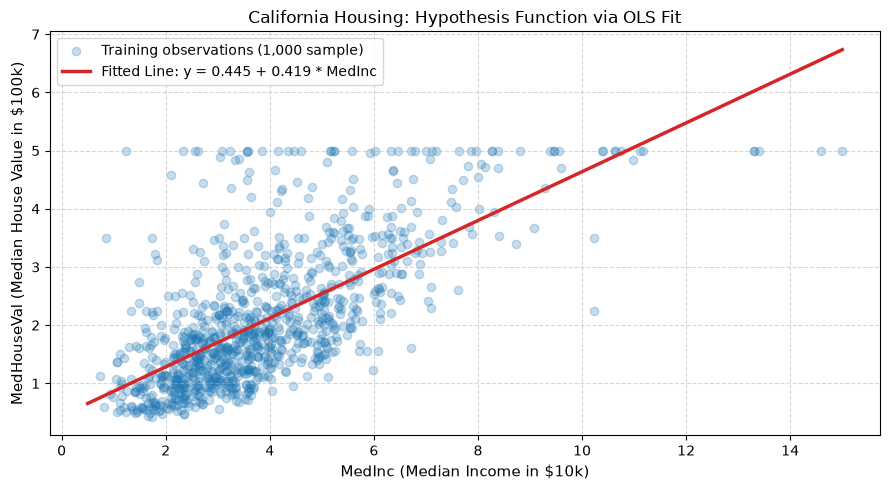

In [13]:
plt.figure(figsize=(9, 5))

# Subsample points for clear visualization
sample_idx = np.random.RandomState(42).choice(len(X_train), size=1000, replace=False)
plt.scatter(
    X_train.iloc[sample_idx]["MedInc"],
    y_train.iloc[sample_idx],
    alpha=0.25,
    color="#1f77b4",
    label="Training observations (1,000 sample)"
)

# Plot fitted regression line
x_line = np.linspace(X_train["MedInc"].min(), X_train["MedInc"].max(), 200)
y_line = h(x_line, beta_0, beta_1)
plt.plot(x_line, y_line, color="#d62728", linewidth=2.5, label=f"Fitted Line: y = {beta_0:.3f} + {beta_1:.3f} * MedInc")

plt.title("California Housing: Hypothesis Function via OLS Fit", fontsize=12)
plt.xlabel("MedInc (Median Income in $10k)", fontsize=11)
plt.ylabel("MedHouseVal (Median House Value in $100k)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 12. Explaining What `.fit()` Did

### The Training Chain:
```
Choose Hypothesis
       ↓
   .fit(X, y)
       ↓
Solver minimizes Loss
       ↓
   Learn beta
       ↓
 Trained Model
```

- **Before `.fit()`**:
  The `LinearRegression` model is initialized with a hypothesis architecture:
  $$h(X, \beta) = \beta_0 + \beta_1 X$$
  However, it has not seen the California Housing data and parameters $\beta$ are undetermined.

- **During `.fit()`**:
  The solver identifies the optimal parameters $\beta^*$ that minimize the squared-error loss:
  $$\min_{\beta_0, \beta_1} \sum_{i=1}^N \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2$$
  *Note*: scikit-learn solves this least-squares problem using numerical linear algebra (specifically Singular Value Decomposition / LAPACK `gelsd`), not brute-force iteration.

- **After `.fit()`**:
  The learned parameters are stored in:
  - `model.intercept_` ($\beta_0 = 0.444597$)
  - `model.coef_` ($\beta_1 = 0.419338$)
  Predictions can now be computed deterministically for any input value.

# 13. Parameter vs Hyperparameter Preview

- **Parameters (Learned)**:
  Values computed during `.fit()` directly from the training data:
  $$\beta_0, \beta_1$$
- **Hyperparameters (Configured)**:
  Settings chosen by the practitioner *before* calling `.fit()`, such as:
  `fit_intercept=True`, `copy_X=True`

*(A comprehensive study of hyperparameters versus parameters will be conducted in subsequent lessons.)*

# 14. Step 1 Programmatic Verification

We run automated assertions confirming all requirements of Step 1 are strictly fulfilled.

In [14]:
# Programmatic verifications
assert data.shape == (20640, 9), f"Unexpected data shape: {data.shape}"
assert len(data.columns) == 9, "Unexpected number of columns"
assert "MedHouseVal" in data.columns, "MedHouseVal target missing"
assert data.isnull().sum().sum() == 0, "Found unexpected missing values"
assert data.duplicated().sum() == 0, "Found unexpected duplicate rows"

assert X.columns.tolist() == ["MedInc"], f"X should contain only MedInc, found {X.columns.tolist()}"
assert y.name == "MedHouseVal", "y should be MedHouseVal"
assert len(X_train) == 16512 and len(X_test) == 4128, "Incorrect split sizes"
assert isinstance(model, LinearRegression), "Model is not LinearRegression"
assert np.isclose(beta_0, model.intercept_), "beta_0 mismatch"
assert np.isclose(beta_1, model.coef_[0]), "beta_1 mismatch"

# Hypothesis predictions check
test_preds = model.predict(X_test)
manual_test_preds = h(X_test["MedInc"].values, beta_0, beta_1)
assert np.allclose(test_preds, manual_test_preds), "Predictions do not match"

# Residual check
calc_residuals = y_test - test_preds
assert np.allclose(calc_residuals, residuals), "Residual mismatch"
assert ssr >= 0, "SSR must be non-negative"
assert mse >= 0, "MSE must be non-negative"

# Check that loss at learned beta_0 is strictly smaller than at candidate offsets
learned_train_ssr = np.sum((y_train.values - h(X_train["MedInc"].values, beta_0, beta_1)) ** 2)
for d in [-0.20, -0.10, -0.05, 0.05, 0.10, 0.20]:
    cand_ssr = np.sum((y_train.values - h(X_train["MedInc"].values, beta_0 + d, beta_1)) ** 2)
    assert cand_ssr > learned_train_ssr, f"Learned beta_0 is not optimal compared to delta {d}"

# Verify out-of-scope items: no scaling applied yet (raw data has mean ~3.88 and std ~1.90, not standard normal)
assert 3.5 < X_train["MedInc"].mean() < 4.2, f"Data was unexpectedly scaled! Mean: {X_train['MedInc'].mean()}"
assert 1.5 < X_train["MedInc"].std() < 2.5, f"Data was unexpectedly scaled! Std: {X_train['MedInc'].std()}"

print("✓ All Step 1 programmatic verifications passed successfully!")

✓ All Step 1 programmatic verifications passed successfully!
